# Environment Exploration

This notebook introduces the `SimpleHVACEnv` — a custom Gymnasium environment for HVAC control — and verifies that it works correctly before any controller or RL agent is applied.

## What this notebook covers
1. **Inspect the observation and action spaces** — what the agent sees and can do
2. **Run a random policy** — establish a performance baseline with no intelligence
3. **Visualize temperature and reward dynamics** — understand how the environment behaves

## The environment

| Property | Value |
|---|---|
| Observation | `[indoor_temp, outdoor_temp]` — two floats in [0, 50] |
| Action | `Discrete(3)` — 0 = cool, 1 = off, 2 = heat |
| Comfort zone | 21–23°C |
| Reward | Negative comfort penalty + negative energy cost |

A random policy selects actions uniformly at random, which means it will frequently heat when it should cool and vice versa. This gives us a lower-bound baseline.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from rl_hvac_control.env.hvac_env import SimpleHVACEnv

## 1. Inspect the spaces

The observation space tells us the range and dtype of inputs the agent will receive. The action space defines the discrete choices available at each step.

In [2]:
env = SimpleHVACEnv()

obs, _ = env.reset()

print("Initial observation:", obs)
print("  obs[0] = indoor temperature:", obs[0], "°C")
print("  obs[1] = outdoor temperature:", obs[1], "°C")
print("Action space:", env.action_space)
print("  0 = cool, 1 = off, 2 = heat")
print("Observation space:", env.observation_space)

Initial observation: [25. 30.]
  obs[0] = indoor temperature: 25.0 °C
  obs[1] = outdoor temperature: 30.0 °C
Action space: Discrete(3)
  0 = cool, 1 = off, 2 = heat
Observation space: Box(0.0, 50.0, (2,), float32)


## 2. Run a random policy

We sample actions uniformly at random for 100 steps. This is the worst plausible policy — it establishes a floor that any real controller should beat.

In [3]:
temps = []
rewards = []

obs, _ = env.reset()

for _ in range(100):

    action = env.action_space.sample()

    obs, reward, done, _, _ = env.step(action)

    temps.append(obs[0])
    rewards.append(reward)

## 3. Visualize

The dashed line marks the center of the comfort band (22°C). A good controller should keep the temperature close to this line. The random policy drifts widely — notice how often it overshoots in both directions.

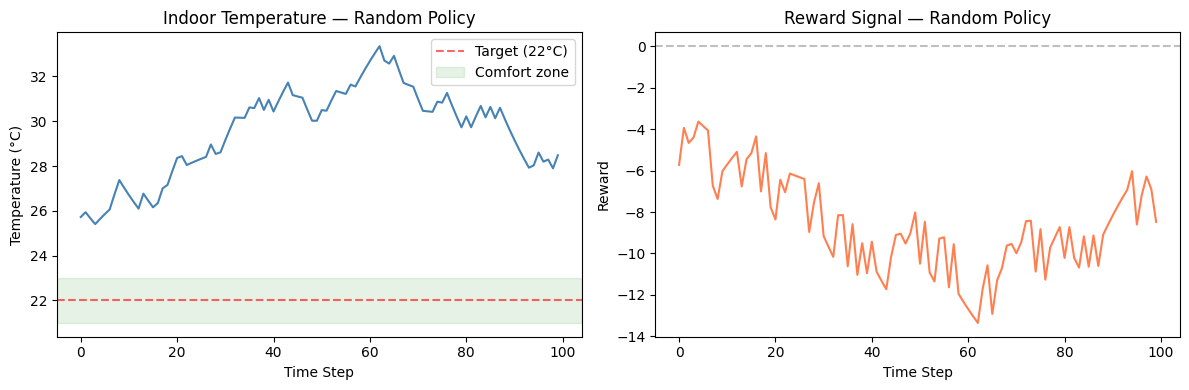

Total reward (random policy): -858.91
Steps in comfort zone [21-23°C]: 0/100


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(temps, color='steelblue')
axes[0].axhline(22, linestyle='--', color='red', alpha=0.6, label='Target (22°C)')
axes[0].axhspan(21, 23, alpha=0.1, color='green', label='Comfort zone')
axes[0].set_title("Indoor Temperature — Random Policy")
axes[0].set_xlabel("Time Step")
axes[0].set_ylabel("Temperature (°C)")
axes[0].legend()

axes[1].plot(rewards, color='coral')
axes[1].axhline(0, linestyle='--', color='gray', alpha=0.5)
axes[1].set_title("Reward Signal — Random Policy")
axes[1].set_xlabel("Time Step")
axes[1].set_ylabel("Reward")

plt.tight_layout()
plt.show()

print(f"Total reward (random policy): {sum(rewards):.2f}")
print(f"Steps in comfort zone [21-23°C]: {sum(21 <= t <= 23 for t in temps)}/100")

## Summary

The random policy establishes a hard lower bound. Any real controller — rule-based, PID, or RL — should achieve a significantly higher total reward and spend more steps inside the comfort band.

**Next**: See `controller_comparison.ipynb` to compare the rule-based and PID controllers, then `train_ppo.ipynb` to train an RL agent.